In [1]:
import numpy as np
import time
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [16]:
class MomentumGD():

    def __init__(self, target = "regression", learning_rate=0.01, attenuation=0.9, tolerance=1e-8,
                 force_center=0.0,          
                 force_elastic=0.0,         
                 force_margin=0.0,         
                 temperature=0.0, 
                 timeout=10,
                 max_iterations=500,
                 decay_rate=0.01):
        self.target = target
        self.lr = learning_rate
        self.beta = attenuation
        self.force_center = force_center
        self.force_elastic = force_elastic
        self.force_margin = force_margin
        self.temperature = temperature
        self.tol = tolerance
        self.timeout = timeout
        self.max_iterations = max_iterations
        self.decay_rate = decay_rate
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        v_w = np.zeros(n_features)
        v_b = 0
        self.w = np.zeros(n_features)
        self.b = 0
        start=time.time()
        prev_loss = np.inf

        center = np.mean(X, axis=0)
        self.best_w = self.w.copy()
        self.best_loss = prev_loss
        
        for iter in range(self.max_iterations):

            #self.lr = self.lr * (1 - iter / self.max_iterations)
            #self.lr = self.lr * (self.decay_rate ** iter)
            
            w_lookahead = self.w + self.beta * v_w
            b_lookahead = self.b + self.beta * v_b
            
            pred = w_lookahead @ X.T + b_lookahead   #Nesterov вариант (мы смотрим на траекторию (вектор v) заранее перед вычислением
                                                     #влияющей силы (градиент)
            #pred = self.w @ X.T + self.b
            errors = pred - y
            loss = np.mean(errors**2)
            self.loss_history.append(loss)
            
            dw = (2 / n_samples) * X.T @ errors
            db = (2 / n_samples) * np.sum(errors)
            
            # 1. Центростремительная сила (тянет к центру данных)
            if self.force_center != 0:
                dw += self.force_center * (w_lookahead - center)
            
            # 2. Упругая сила (возвращает к лучшему решению)
            if self.force_elastic != 0:
                dw += self.force_elastic * (w_lookahead - self.best_w)
            
            # 3. Маржинальная сила (отталкивает от границы) only классификация
            if self.target == "classification" and self.force_margin != 0:
                margin = np.abs(pred)
                margin_force = -self.force_margin * np.sign(w_lookahead) * np.maximum(0, 1 - margin)
                dw += margin_force
            
            # 4. Случайная сила (термостат)
            if self.temperature != 0:
                dw += self.temperature * np.random.randn(n_features)
            
            v_w = self.beta * v_w - self.lr * dw
            v_b = self.beta * v_b - self.lr * db
            
            self.w += v_w
            self.b += v_b

            if loss < self.best_loss:
                self.best_loss = loss
                self.best_w = self.w.copy()

            if np.abs(prev_loss - loss) < self.tol:
                print(f'converged in {iter}')
                break

            prev_loss = loss

        return self

    def predict(self,X):
        return self.w @ X.T + self.b
        

Форма: (10000, 10)
Диапазон target: [-605.89, 586.45]
Масштабированный диапазон target: [-3.77, 3.65]
Стандартный Momentum
converged in 109
MSE: 96.6063
MAE: 7.7943
R²: 0.9963
Финальный loss: 0.003866
+ Центростремительная сила
converged in 140
MSE: 97.2255
MAE: 7.8121
R²: 0.9963
Финальный loss: 0.003891
+ Упругая сила
converged in 109
MSE: 96.6041
MAE: 7.7943
R²: 0.9963
Финальный loss: 0.003866
+ Термостат (шум)
converged in 114
MSE: 96.5590
MAE: 7.7938
R²: 0.9963
Финальный loss: 0.003866
sklearn (эталон)
MSE: 96.5643
MAE: 7.7924
R²: 0.9963


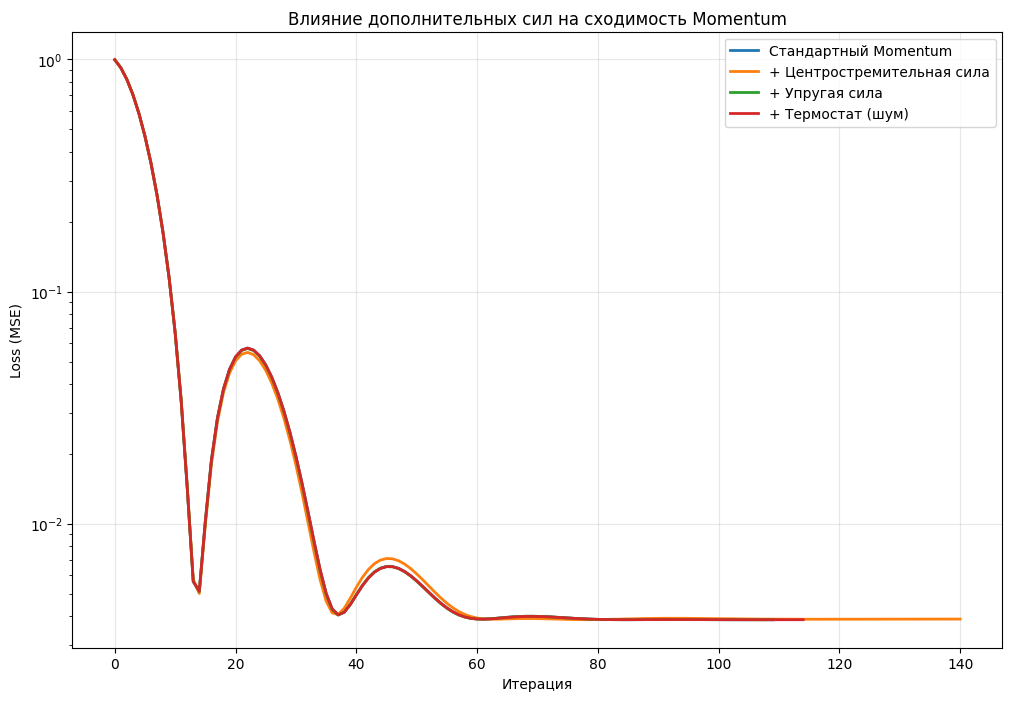

In [128]:
X, y = make_regression(
    n_samples=10000,         
    n_features=10,            
    #n_informative=5,      
    noise=10,               
    random_state=42
)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Форма: {X.shape}")
print(f"Диапазон target: [{y.min():.2f}, {y.max():.2f}]")
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
print(f"Масштабированный диапазон target: [{y.min():.2f}, {y.max():.2f}]")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

configs = [
    {"name": "Стандартный Momentum", "force_center": 0, "force_elastic": 0, "force_margin": 0, "temperature": 0},
    {"name": "+ Центростремительная сила", "force_center": 0.01, "force_elastic": 0, "force_margin": 0, "temperature": 0},
    {"name": "+ Упругая сила", "force_center": 0, "force_elastic": 0.01, "force_margin": 0, "temperature": 0},
    {"name": "+ Термостат (шум)", "force_center": 0, "force_elastic": 0, "force_margin": 0, "temperature": 0.001},
]

plt.figure(figsize=(12, 8))

for config in configs:
    model = MomentumGD(
    target="regression",
    learning_rate=0.01,
    attenuation=0.9,
    force_center=config["force_center"],
    force_elastic=config["force_elastic"],
    temperature=config["temperature"],
    tolerance=1e-8,
    timeout=5,
    max_iterations = 500
    )
                                
    print(f'{config["name"]}')
    model.fit(X_train, y_train)
    y_pred_scaled = model.predict(X_test)
                                
    # Обратное масштабирование
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    # Метрики на исходном масштабе
    mse = mean_squared_error(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    r2 = r2_score(y_test_original, y_pred)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Финальный loss: {model.loss_history[-1]:.6f}")
    
    plt.plot(model.loss_history, linewidth=2, label=config["name"])

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr_scaled = lr.predict(X_test)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

mse_lr = mean_squared_error(y_test_original, y_pred_lr)
mae_lr = mean_absolute_error(y_test_original, y_pred_lr)
r2_lr = r2_score(y_test_original, y_pred_lr)

print("sklearn (эталон)")
print(f"MSE: {mse_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

plt.xlabel('Итерация')
plt.ylabel('Loss (MSE)')
plt.title('Влияние дополнительных сил на сходимость Momentum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

In [129]:
class AdaGradNorm():
    
    def __init__(self, target = "regression", D=0.01, tolerance=1e-8, timeout=5, max_iterations=500):
        self.target = target
        self.D = D
        self.tol = tolerance
        self.timeout = timeout
        self.max_iterations = max_iterations
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        G_w = 0
        G_b = 0
        self.w = np.zeros(n_features)
        self.b = 0
        start=time.time()
        prev_loss = np.inf
        
        for iteration in range(self.max_iterations):
            if time.time() - start > self.timeout:
                print(f'Timeout at iteration {iteration}')
                break
                
            pred = X @ self.w + self.b
            errors = pred - y
            loss = np.mean(errors**2)
            self.loss_history.append(loss)
            
            dw = (2 / n_samples) * X.T @ errors
            db = (2 / n_samples) * np.sum(errors)

            norm_w = np.linalg.norm(dw)**2
            norm_b = db**2
            G_w = G_w + norm_w
            G_b = G_b + norm_b

            self.w -= self.D / np.sqrt(G_w + 1e-12) * dw
            self.b -= self.D / np.sqrt(G_b+ 1e-12) * db

            if np.abs(loss-prev_loss) <= self.tol:
                print(f'converged in {iteration}')
                break
            
            prev_loss = loss

        return self

    def predict(self,X):
        return self.w @ X.T + self.b

converged in 341
MSE: 96.3569
MAE: 7.8000
R²: 0.9963


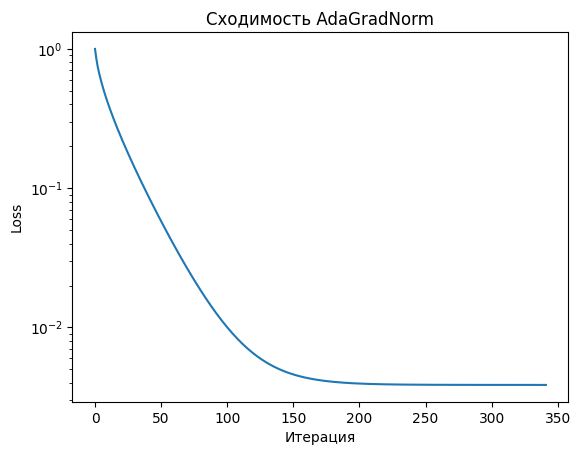

In [130]:
X, y = make_regression(n_samples=10000, n_features=10, noise=10, random_state=42)

# Нормализация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=43)

# Создание и обучение модели
agn = AdaGradNorm(
    D=0.07916,             
    max_iterations=500,
    tolerance=1e-8,
    timeout=1
)

agn.fit(X_train, y_train)

y_pred_scaled_agn = agn.predict(X_test)
                                
y_pred_agn = scaler_y.inverse_transform(y_pred_scaled_agn.reshape(-1, 1)).ravel()
y_test_original_agn = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

mse_agn = mean_squared_error(y_test_original_agn, y_pred_agn)
mae_agn = mean_absolute_error(y_test_original_agn, y_pred_agn)
r2_agn = r2_score(y_test_original_agn, y_pred_agn)

print(f"MSE: {mse_agn:.4f}")
print(f"MAE: {mae_agn:.4f}")
print(f"R²: {r2_agn:.4f}")

plt.plot(agn.loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость AdaGradNorm')
plt.yscale('log')
plt.show()

In [48]:
class AdaGrad():
    
    def __init__(self, target = "regression", D=0.01, tolerance=1e-7, timeout=5, max_iterations=500):
        self.target = target
        self.D = D
        self.tol = tolerance
        self.timeout = timeout
        self.max_iterations = max_iterations
        self.eps = 1e-12
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        G_w = np.zeros(n_features)
        G_b = 0
        self.w = np.zeros(n_features)
        self.b = 0
        start=time.time()
        prev_loss = np.inf
        
        for iteration in range(self.max_iterations):
            if time.time() - start > self.timeout:
                print(f'Timeout at iteration {iteration}')
                break
                
            pred = X @ self.w + self.b
            errors = pred - y
            loss = np.mean(errors**2)
            self.loss_history.append(loss)
                
            dw = (2 / n_samples) * X.T @ errors
            db = (2 / n_samples) * np.sum(errors)                # покоординатно итерационно

            """for i in range(len(self.w)):
                G_w[i] += dw[i]**2
                self.w[i] -= self.D / np.sqrt(G_w[i] + self.eps) * dw[i]"""
                        
            G_w += dw**2                                         # покоординатно векторизованно
            self.w -= self.D / np.sqrt(G_w + self.eps) * dw

            G_b += db**2
            self.b -= self.D / np.sqrt(G_b+ self.eps) * db
            
            if np.abs(loss-prev_loss) <= self.tol:
                print(f'converged in {iteration}')
                break
            
            prev_loss = loss

        return self

    def predict(self,X):
        return self.w @ X.T + self.b

converged in 106
MSE: 96.3706
MAE: 7.8009
R²: 0.9963


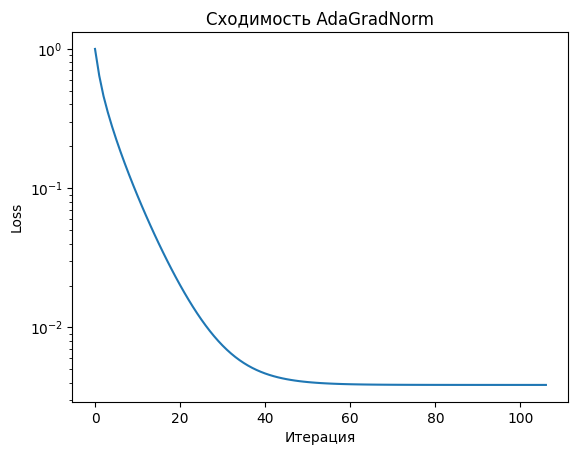

In [49]:
X, y = make_regression(n_samples=10000, n_features=10, noise=10, random_state=42)

# Нормализация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=43)

# Создание и обучение модели
ag = AdaGrad(
    D=0.07916,             
    max_iterations=500,
    tolerance=1e-8,
    timeout=1
)

ag.fit(X_train, y_train)

y_pred_scaled_ag = ag.predict(X_test)
                                
y_pred_ag = scaler_y.inverse_transform(y_pred_scaled_ag.reshape(-1, 1)).ravel()
y_test_original_ag = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

mse_ag = mean_squared_error(y_test_original_ag, y_pred_ag)
mae_ag = mean_absolute_error(y_test_original_ag, y_pred_ag)
r2_ag = r2_score(y_test_original_ag, y_pred_ag)

print(f"MSE: {mse_ag:.4f}")
print(f"MAE: {mae_ag:.4f}")
print(f"R²: {r2_ag:.4f}")

plt.plot(ag.loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость AdaGradNorm')
plt.yscale('log')
plt.show()

In [133]:
class RMSProp():
    
    def __init__(self, target = "regression", D=0.01, attenuation=0.9, decay_rate = 0.1, tolerance=1e-7, timeout=5, max_iterations=500):
        self.target = target
        self.D = D
        self.beta = attenuation
        self.decay_rate = decay_rate
        self.tol = tolerance
        self.timeout = timeout
        self.max_iterations = max_iterations
        self.eps = 1e-12
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape
        G_w = np.zeros(n_features)
        G_b = 0
        self.w = np.zeros(n_features)
        self.b = 0
        start=time.time()
        prev_loss = np.inf
        
        for iteration in range(self.max_iterations):
            if time.time() - start > self.timeout:
                print(f'Timeout at iteration {iteration}')
                break

            lr = self.D / (1 + self.decay_rate * iteration)
                
            pred = X @ self.w + self.b
            errors = pred - y
            loss = np.mean(errors**2)
            self.loss_history.append(loss)
                
            dw = (2 / n_samples) * X.T @ errors
            db = (2 / n_samples) * np.sum(errors)                # покоординатно итерационно

            """for i in range(len(self.w)):
                G_w[i] += dw[i]**2
                self.w[i] -= self.D / np.sqrt(G_w[i] + self.eps) * dw[i]"""
                        
            G_w = self.beta * G_w + (1 - self.beta) * dw**2                                         # покоординатно векторизованно
            self.w -= lr / np.sqrt(G_w + self.eps) * dw

            G_b = self.beta * G_b + (1 - self.beta) * db**2
            self.b -= lr / np.sqrt(G_b+ self.eps) * db
            
            if np.abs(loss-prev_loss) <= self.tol:
                print(f'converged in {iteration}')
                break
            
            prev_loss = loss

        return self

    def predict(self,X):
        return self.w @ X.T + self.b

converged in 1478
MSE: 96.3413
MAE: 7.8001
R²: 0.9963


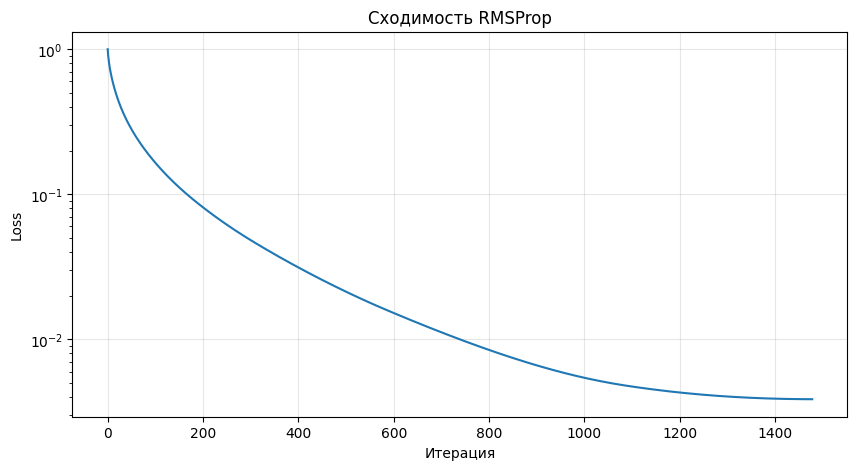

In [134]:
X, y = make_regression(n_samples=10000, n_features=10, noise=10, random_state=42)

# Нормализация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=43)

rmsp = RMSProp(
    D=0.01,                    
    attenuation=0.7,          
    tolerance=1e-7,
    timeout=5,
    max_iterations=10000
)

rmsp.fit(X_train, y_train)

y_pred_scaled_rmsp = rmsp.predict(X_test)
y_pred_rmsp = scaler_y.inverse_transform(y_pred_scaled_rmsp.reshape(-1, 1)).ravel()
y_test_original_rmsp = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

mse_rmsp = mean_squared_error(y_test_original_rmsp, y_pred_rmsp)
mae_rmsp = mean_absolute_error(y_test_original_rmsp, y_pred_rmsp)
r2_rmsp = r2_score(y_test_original_rmsp, y_pred_rmsp)

print(f"MSE: {mse_rmsp:.4f}")
print(f"MAE: {mae_rmsp:.4f}")
print(f"R²: {r2_rmsp:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(rmsp.loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость RMSProp')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [135]:
class Adam():
    
    def __init__(self, target="regression", D=0.01, beta1=0.9, beta2=0.999, decay_rate=0.1, 
                 tolerance=1e-7, timeout=5, max_iterations=500):
        self.target = target
        self.D = D                          
        self.beta1 = beta1                  
        self.beta2 = beta2                  
        self.decay_rate = decay_rate        
        self.tol = tolerance
        self.timeout = timeout
        self.max_iterations = max_iterations
        self.eps = 1e-12
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        

        self.w = np.zeros(n_features)
        self.b = 0
        
        v_w = np.zeros(n_features)      # первый момент
        v_b = 0
        G_w = np.zeros(n_features)      # второй момент
        G_b = 0
        
        start = time.time()
        prev_loss = np.inf
        
        for iteration in range(self.max_iterations):
            if time.time() - start > self.timeout:
                print(f'Timeout at iteration {iteration}')
                break
            
            lr = self.D #/ (1 + self.decay_rate * iteration)

            pred = X @ self.w + self.b
            errors = pred - y
            loss = np.mean(errors ** 2)
            self.loss_history.append(loss)

            dw = (2 / n_samples) * X.T @ errors
            db = (2 / n_samples) * np.sum(errors)
        
            # смещённые оценки
            v_w = self.beta1 * v_w + (1 - self.beta1) * dw
            v_b = self.beta1 * v_b + (1 - self.beta1) * db
            
            G_w = self.beta2 * G_w + (1 - self.beta2) * dw ** 2
            G_b = self.beta2 * G_b + (1 - self.beta2) * db ** 2
            
            # Коррекция смещения
            """t = iteration + 1
            v_w_hat = v_w / (1 - self.beta1 ** t)
            v_b_hat = v_b / (1 - self.beta1 ** t)
            
            G_w_hat = G_w / (1 - self.beta2 ** t)
            G_b_hat = G_b / (1 - self.beta2 ** t)"""
            
            self.w -= lr * v_w / (np.sqrt(G_w) + self.eps)
            self.b -= lr * v_b / (np.sqrt(G_b) + self.eps)
            
            if abs(loss - prev_loss) < self.tol and iteration > 0:
                print(f'Converged at iteration {iteration}')
                break
            
            prev_loss = loss
        
        return self

    def predict(self, X):
        return X @ self.w + self.b

Converged at iteration 82
MSE: 96.2919
MAE: 7.7999
R²: 0.9963


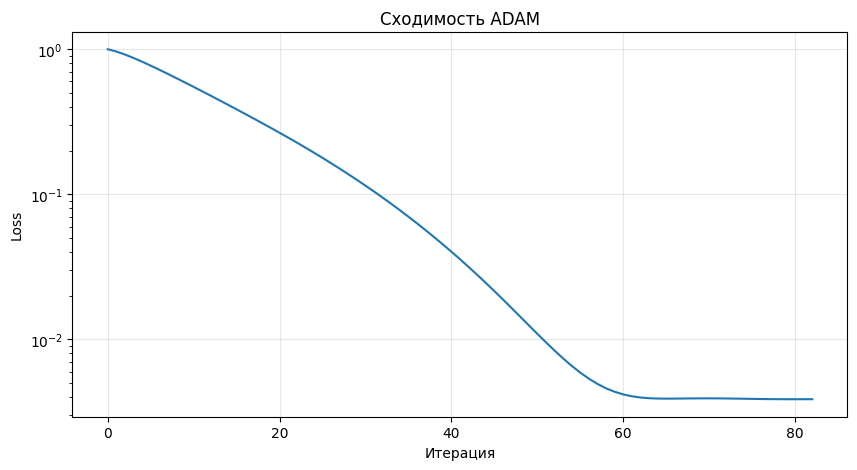

In [136]:
X, y = make_regression(n_samples=10000, n_features=10, noise=10, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=43)

adam = Adam(
    D=0.01,                  
    beta1=0.79,                
    beta2=0.9,              
    tolerance=1e-7,
    timeout=5,
    max_iterations=1000
)

adam.fit(X_train, y_train)

y_pred_scaled_adam = adam.predict(X_test)
y_pred_adam = scaler_y.inverse_transform(y_pred_scaled_adam.reshape(-1, 1)).ravel()
y_test_original_adam = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

mse_adam = mean_squared_error(y_test_original_adam, y_pred_adam)
mae_adam = mean_absolute_error(y_test_original_adam, y_pred_adam)
r2_adam = r2_score(y_test_original_adam, y_pred_adam)

print(f"MSE: {mse_adam:.4f}")
print(f"MAE: {mae_adam:.4f}")
print(f"R²: {r2_adam:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(adam.loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость ADAM')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Выведенные интуитивные особенности алгоритмов:
### 1. Momentum
*Физический смысл: ключевая идея - накопленная инерция (v) и выведенные формулы скорости (v) и перемешения (w) из формулы движения тела с трением*
### 2. AdaGradNorm
*Накапливаем нормы градиентов и определяем по истории градиентов велечину шага (если слишком большое значение истории, значит шаг поменьше)*
### 3. AdaGrad
*Признаки имеют разный масштаб, разреженные данные. В отличие от AdaGradNorm G - это вектор, а не скаляр*
### 4. RMSProp
*Решает проблему большого наколпения G, используя beta по аналогии с Momentum. Но в то же время требует экспоненциального затухания для D, иначен 
ближе к концу он начнет сильно колебаться*
### 5. Adam
*Совмещает в себе Momentum и RMSProp, т.е. накпаливает инерцию и запоминает историю G. Показывает преимущественно наискорейшее схождение и точность.*

# Итоговое сравнение всех алгоритмов (+применение физ. сил из Моментума)

СРАВНЕНИЕ ОПТИМИЗАТОРОВ

ДАТАСЕТ: regression (linear)
converged in 122

Momentum Standard:
  MSE: 101.9169
  MAE: 8.0071
  R²:  0.9973
  Fit time: 0.0902 сек
  Predict time: 0.0003 сек
converged in 121

Momentum + Center:
  MSE: 102.7576
  MAE: 8.0344
  R²:  0.9972
  Fit time: 0.0913 сек
  Predict time: 0.0006 сек
converged in 122

Momentum + Elastic:
  MSE: 101.9168
  MAE: 8.0071
  R²:  0.9973
  Fit time: 0.0660 сек
  Predict time: 0.0003 сек
converged in 117

Momentum + Temperature:
  MSE: 102.1015
  MAE: 8.0137
  R²:  0.9973
  Fit time: 0.0622 сек
  Predict time: 0.0003 сек
converged in 145

Momentum + Center+Elastic:
  MSE: 102.8300
  MAE: 8.0378
  R²:  0.9972
  Fit time: 0.0855 сек
  Predict time: 0.0003 сек
converged in 93

Momentum + All Forces:
  MSE: 103.5835
  MAE: 8.0714
  R²:  0.9972
  Fit time: 0.0497 сек
  Predict time: 0.0003 сек
converged in 89

AdaGrad:
  MSE: 101.9264
  MAE: 8.0067
  R²:  0.9973
  Fit time: -2.6470 сек
  Predict time: 0.0003 сек
converged in 380

AdaG

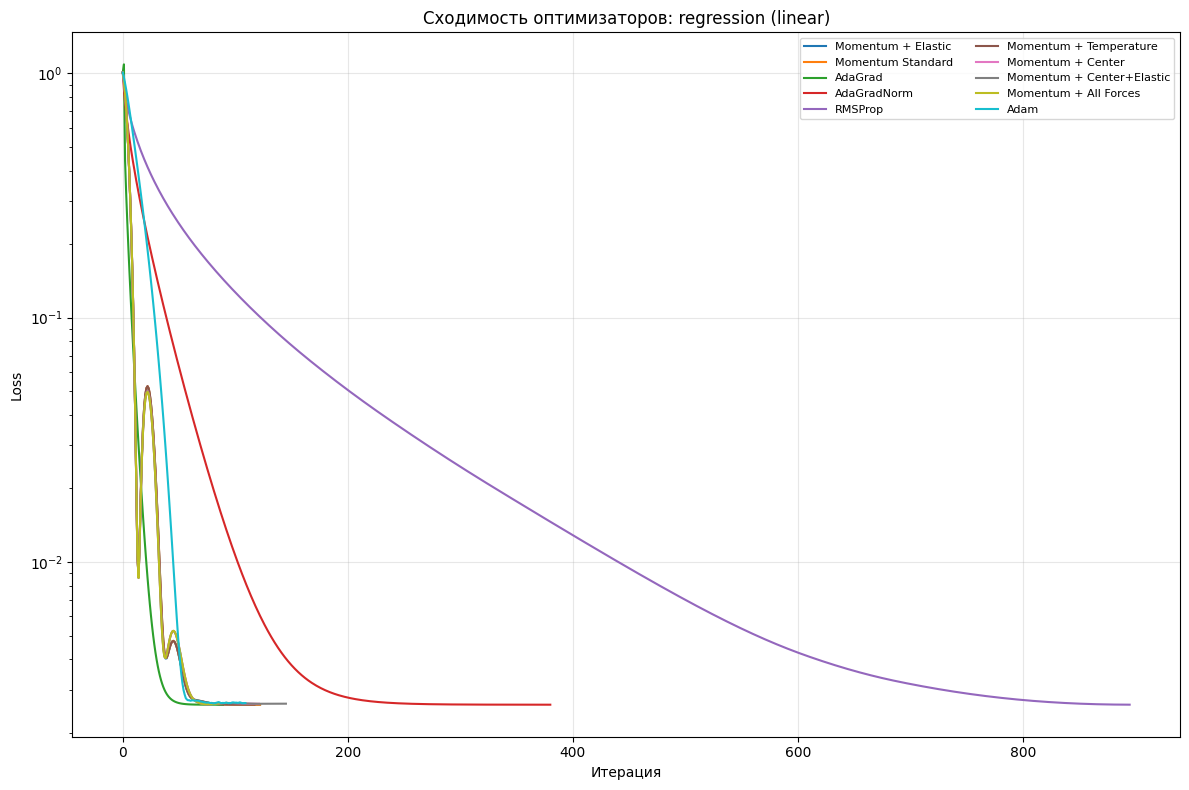


ДАТАСЕТ: friedman1 (non-linear)
converged in 120

Momentum Standard:
  MSE: 32.0659
  MAE: 4.5057
  R²:  0.3625
  Fit time: 0.1420 сек
  Predict time: 0.0003 сек
converged in 77

Momentum + Center:
  MSE: 32.0660
  MAE: 4.5056
  R²:  0.3625
  Fit time: 0.0780 сек
  Predict time: 0.0002 сек
converged in 119

Momentum + Elastic:
  MSE: 32.0659
  MAE: 4.5057
  R²:  0.3625
  Fit time: 0.1333 сек
  Predict time: 0.0002 сек
converged in 108

Momentum + Temperature:
  MSE: 32.0675
  MAE: 4.5059
  R²:  0.3625
  Fit time: 0.1258 сек
  Predict time: 0.0002 сек
converged in 140

Momentum + Center+Elastic:
  MSE: 32.0583
  MAE: 4.5054
  R²:  0.3627
  Fit time: 0.1591 сек
  Predict time: 0.0002 сек
converged in 192

Momentum + All Forces:
  MSE: 32.0581
  MAE: 4.5053
  R²:  0.3627
  Fit time: 0.2295 сек
  Predict time: 0.0002 сек
converged in 75

AdaGrad:
  MSE: 32.0650
  MAE: 4.5056
  R²:  0.3625
  Fit time: 0.1098 сек
  Predict time: 0.0002 сек
converged in 159

AdaGradNorm:
  MSE: 32.0650
  MAE

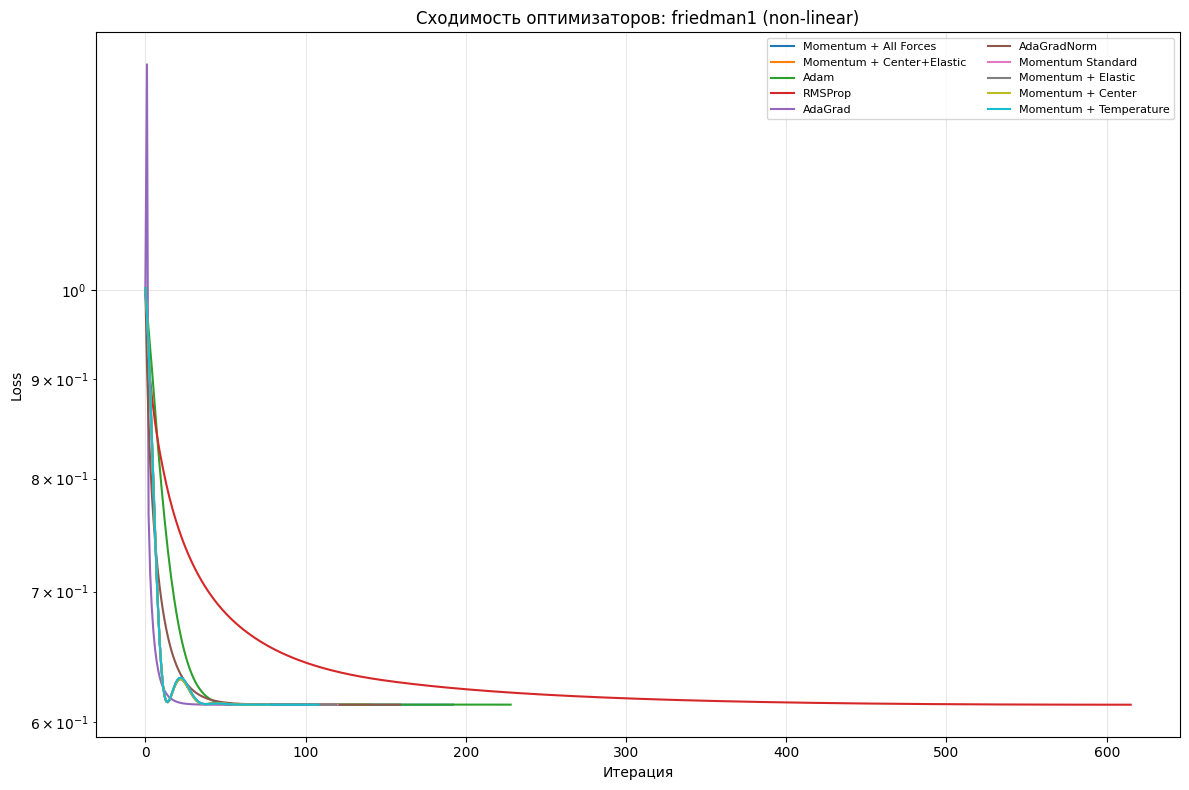


ИТОГОВАЯ ТАБЛИЦА (СРЕДНИЕ ЗНАЧЕНИЯ ПО ДВУМ ДАТАСЕТАМ)
Алгоритм                            MSE          MAE          R²         Fit Time  
-------------------------------------------------------------------------------
Momentum Standard                   66.9875      6.2562       0.67997267 0.14774144
Momentum + Center                   66.9876      6.2563       0.67997103 0.12468433
Momentum + Elastic                  66.9893      6.2557       0.67994700 0.13803434
Momentum + Temperature              66.9944      6.2561       0.67993006 -0.84859133
Momentum + Center+Elastic           67.0048      6.2556       0.67990390 0.15566623
Momentum + All Forces               67.0259      6.2572       0.67990316 1.98362613
AdaGrad                             67.0833      6.2597       0.67990151 0.08153963
AdaGradNorm                         67.4117      6.2700       0.67988460 0.11661828
RMSProp                             67.4480      6.2717       0.67988295 0.10936260
Adam                    

In [160]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_friedman1
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# ============== ВАШИ ГОТОВЫЕ КЛАССЫ ==============
# (MomentumGD, AdaGrad, AdaGradNorm, RMSProp, Adam - предполагаются уже определёнными)

# ============== ВАРИАНТЫ MOMENTUMGD С РАЗНЫМИ СИЛАМИ ==============

class MomentumGD_Standard(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.0, force_elastic=0.0, temperature=0.0, force_margin=0.0, **kwargs)

class MomentumGD_Center(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.01, force_elastic=0.0, temperature=0.0, force_margin=0.0, **kwargs)

class MomentumGD_Elastic(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.0, force_elastic=0.01, temperature=0.0, force_margin=0.0, **kwargs)

class MomentumGD_Temperature(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.0, force_elastic=0.0, temperature=0.001, force_margin=0.0, **kwargs)

class MomentumGD_CenterElastic(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.01, force_elastic=0.01, temperature=0.0, force_margin=0.0, **kwargs)

class MomentumGD_All(MomentumGD):
    def __init__(self, **kwargs):
        super().__init__(force_center=0.01, force_elastic=0.01, temperature=0.001, force_margin=0.0, **kwargs)


# ============== ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ ПОЛЬЗОВАТЕЛЬСКИХ АЛГОРИТМОВ ==============

def test_algorithm(algorithm_class, algorithm_name, params, X_train, y_train, X_test, y_test, scaler_y):
    start_time = time.time()
    model = algorithm_class(**params)
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    start_time = time.time()
    y_pred_scaled = model.predict(X_test)
    predict_time = time.time() - start_time
    
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    mse = mean_squared_error(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    r2 = r2_score(y_test_original, y_pred)
    
    return {
        'name': algorithm_name,
        'model': model,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'fit_time': fit_time,
        'predict_time': predict_time,
        'loss_history': model.loss_history
    }


# ============== ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ SKLEARN МОДЕЛЕЙ ==============

def test_sklearn_model(model, model_name, X_train, y_train, X_test, y_test, scaler_y):
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    start_time = time.time()
    y_pred_scaled = model.predict(X_test)
    predict_time = time.time() - start_time
    
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    mse = mean_squared_error(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    r2 = r2_score(y_test_original, y_pred)
    
    return {
        'name': model_name,
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'fit_time': fit_time,
        'predict_time': predict_time,
        'loss_history': None
    }


# ============== ДАННЫЕ ==============

print("="*80)
print("СРАВНЕНИЕ ОПТИМИЗАТОРОВ")
print("="*80)

# Датасет 1: make_regression
X1, y1 = make_regression(n_samples=10000, n_features=100, noise=10, random_state=42)

# Датасет 2: make_friedman1 (нелинейный)
X2, y2 = make_friedman1(n_samples=10000, n_features=100, noise=5.0, random_state=42)

datasets = [
    ('regression (linear)', X1, y1),
    ('friedman1 (non-linear)', X2, y2)
]

# Все алгоритмы со своими параметрами
algorithms = [
    # Momentum вариации
    (MomentumGD_Standard, 'Momentum Standard', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
    (MomentumGD_Center, 'Momentum + Center', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
    (MomentumGD_Elastic, 'Momentum + Elastic', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
    (MomentumGD_Temperature, 'Momentum + Temperature', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
    (MomentumGD_CenterElastic, 'Momentum + Center+Elastic', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
    (MomentumGD_All, 'Momentum + All Forces', {'learning_rate': 0.01, 'attenuation': 0.9, 'max_iterations': 500}),
       
    # Другие алгоритмы
    (AdaGrad, 'AdaGrad', {'tolerance' : 1e-8,'D': 0.07916, 'max_iterations': 500}),
    (AdaGradNorm, 'AdaGradNorm', {'tolerance' : 1e-8,'D': 0.07916, 'max_iterations': 500}),
    (RMSProp, 'RMSProp', {'tolerance' : 1e-7,'D': 0.01, 'attenuation': 0.7, 'max_iterations': 2000}),
    (Adam, 'Adam', {'tolerance' : 1e-7,'D': 0.01, 'beta1': 0.79, 'beta2': 0.9, 'max_iterations': 1000})
]

# Результаты
all_results = {}

for dataset_name, X, y in datasets:
    print(f"\n{'='*80}")
    print(f"ДАТАСЕТ: {dataset_name}")
    print(f"{'='*80}")
    
    # Нормализация
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
    
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)
    
    dataset_results = []
    
    # Тестирование пользовательских алгоритмов
    for algorithm_class, algo_name, params in algorithms:
        result = test_algorithm(algorithm_class, algo_name, params, 
                                X_train, y_train, X_test, y_test, scaler_y)
        dataset_results.append(result)
        print(f"\n{algo_name}:")
        print(f"  MSE: {result['mse']:.4f}")
        print(f"  MAE: {result['mae']:.4f}")
        print(f"  R²:  {result['r2']:.4f}")
        print(f"  Fit time: {result['fit_time']:.4f} сек")
        print(f"  Predict time: {result['predict_time']:.4f} сек")
    
    # Тестирование LinearRegression
    lr_model = LinearRegression()
    lr_result = test_sklearn_model(lr_model, 'LinearRegression (sklearn)', 
                                    X_train, y_train, X_test, y_test, scaler_y)
    dataset_results.append(lr_result)
    print(f"\n{lr_result['name']}:")
    print(f"  MSE: {lr_result['mse']:.4f}")
    print(f"  MAE: {lr_result['mae']:.4f}")
    print(f"  R²:  {lr_result['r2']:.4f}")
    print(f"  Fit time: {lr_result['fit_time']:.4f} сек")
    print(f"  Predict time: {lr_result['predict_time']:.4f} сек")
    
    # Тестирование SVR
    svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    svr_result = test_sklearn_model(svr_model, 'SVR (sklearn)', 
                                     X_train, y_train, X_test, y_test, scaler_y)
    dataset_results.append(svr_result)
    print(f"\n{svr_result['name']}:")
    print(f"  MSE: {svr_result['mse']:.4f}")
    print(f"  MAE: {svr_result['mae']:.4f}")
    print(f"  R²:  {svr_result['r2']:.4f}")
    print(f"  Fit time: {svr_result['fit_time']:.4f} сек")
    print(f"  Predict time: {svr_result['predict_time']:.4f} сек")
    
    # Тестирование DecisionTreeRegressor
    dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    dt_result = test_sklearn_model(dt_model, 'DecisionTreeRegressor (sklearn)', 
                                    X_train, y_train, X_test, y_test, scaler_y)
    dataset_results.append(dt_result)
    print(f"\n{dt_result['name']}:")
    print(f"  MSE: {dt_result['mse']:.4f}")
    print(f"  MAE: {dt_result['mae']:.4f}")
    print(f"  R²:  {dt_result['r2']:.4f}")
    print(f"  Fit time: {dt_result['fit_time']:.4f} сек")
    print(f"  Predict time: {dt_result['predict_time']:.4f} сек")
    
    # Тестирование KNeighborsRegressor
    knn_model = KNeighborsRegressor(n_neighbors=5)
    knn_result = test_sklearn_model(knn_model, 'KNeighborsRegressor (sklearn)', 
                                     X_train, y_train, X_test, y_test, scaler_y)
    dataset_results.append(knn_result)
    print(f"\n{knn_result['name']}:")
    print(f"  MSE: {knn_result['mse']:.4f}")
    print(f"  MAE: {knn_result['mae']:.4f}")
    print(f"  R²:  {knn_result['r2']:.4f}")
    print(f"  Fit time: {knn_result['fit_time']:.4f} сек")
    print(f"  Predict time: {knn_result['predict_time']:.4f} сек")
    
    all_results[dataset_name] = dataset_results
    
    # ============== ВЫВОД ТАБЛИЦЫ ДЛЯ ДАТАСЕТА ==============
    print(f"\n{'='*80}")
    print(f"РЕЗУЛЬТАТЫ ДЛЯ {dataset_name}")
    print(f"{'='*80}")
    print(f"{'Алгоритм':<35} {'MSE':<12} {'MAE':<12} {'R²':<10} {'Fit Time':<10} {'Predict Time':<10}")
    print("-"*89)
    
    dataset_results.sort(key=lambda x: x['mse'])
    for result in dataset_results:
        fit_time_str = f"{result['fit_time']:.8f}" if result['fit_time'] < 0.1 else f"{result['fit_time']:.4f}"
        pred_time_str = f"{result['predict_time']:.8f}" if result['predict_time'] < 0.1 else f"{result['predict_time']:.4f}"
        print(f"{result['name']:<35} {result['mse']:<12.4f} {result['mae']:<12.4f} {result['r2']:<10.4f} {fit_time_str:<12} {pred_time_str:<12}")
    
    # График сходимости (только для алгоритмов с loss_history)
    plt.figure(figsize=(12, 8))
    for result in dataset_results:
        if result['loss_history'] is not None:
            plt.plot(result['loss_history'], label=result['name'], linewidth=1.5)
    plt.xlabel('Итерация')
    plt.ylabel('Loss')
    plt.title(f'Сходимость оптимизаторов: {dataset_name}')
    plt.legend(loc='upper right', fontsize=8, ncol=2)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============== ИТОГОВАЯ ТАБЛИЦА ==============

print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА (СРЕДНИЕ ЗНАЧЕНИЯ ПО ДВУМ ДАТАСЕТАМ)")
print("="*80)
print(f"{'Алгоритм':<35} {'MSE':<12} {'MAE':<12} {'R²':<10} {'Fit Time':<10}")
print("-"*79)

# Усреднение с сортировкой по MSE
results_summary = []
total_algos = len(algorithms) + 4  # +4 для LinearRegression, SVR, DecisionTree, KNN

for algo_idx in range(total_algos):
    if algo_idx < len(algorithms):
        _, algo_name, _ = algorithms[algo_idx]
        avg_mse = np.mean([all_results['regression (linear)'][algo_idx]['mse'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mse']])
        avg_mae = np.mean([all_results['regression (linear)'][algo_idx]['mae'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mae']])
        avg_r2 = np.mean([all_results['regression (linear)'][algo_idx]['r2'], 
                          all_results['friedman1 (non-linear)'][algo_idx]['r2']])
        avg_fit = np.mean([all_results['regression (linear)'][algo_idx]['fit_time'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['fit_time']])
        
        results_summary.append({
            'name': algo_name,
            'mse': avg_mse,
            'mae': avg_mae,
            'r2': avg_r2,
            'fit_time': avg_fit
        })
    elif algo_idx == len(algorithms):
        # LinearRegression
        avg_mse = np.mean([all_results['regression (linear)'][algo_idx]['mse'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mse']])
        avg_mae = np.mean([all_results['regression (linear)'][algo_idx]['mae'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mae']])
        avg_r2 = np.mean([all_results['regression (linear)'][algo_idx]['r2'], 
                          all_results['friedman1 (non-linear)'][algo_idx]['r2']])
        avg_fit = np.mean([all_results['regression (linear)'][algo_idx]['fit_time'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['fit_time']])
        
        results_summary.append({
            'name': 'LinearRegression (sklearn)',
            'mse': avg_mse,
            'mae': avg_mae,
            'r2': avg_r2,
            'fit_time': avg_fit
        })
    elif algo_idx == len(algorithms) + 1:
        # SVR
        avg_mse = np.mean([all_results['regression (linear)'][algo_idx]['mse'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mse']])
        avg_mae = np.mean([all_results['regression (linear)'][algo_idx]['mae'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mae']])
        avg_r2 = np.mean([all_results['regression (linear)'][algo_idx]['r2'], 
                          all_results['friedman1 (non-linear)'][algo_idx]['r2']])
        avg_fit = np.mean([all_results['regression (linear)'][algo_idx]['fit_time'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['fit_time']])
        
        results_summary.append({
            'name': 'SVR (sklearn)',
            'mse': avg_mse,
            'mae': avg_mae,
            'r2': avg_r2,
            'fit_time': avg_fit
        })
    elif algo_idx == len(algorithms) + 2:
        # DecisionTreeRegressor
        avg_mse = np.mean([all_results['regression (linear)'][algo_idx]['mse'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mse']])
        avg_mae = np.mean([all_results['regression (linear)'][algo_idx]['mae'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mae']])
        avg_r2 = np.mean([all_results['regression (linear)'][algo_idx]['r2'], 
                          all_results['friedman1 (non-linear)'][algo_idx]['r2']])
        avg_fit = np.mean([all_results['regression (linear)'][algo_idx]['fit_time'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['fit_time']])
        
        results_summary.append({
            'name': 'DecisionTreeRegressor (sklearn)',
            'mse': avg_mse,
            'mae': avg_mae,
            'r2': avg_r2,
            'fit_time': avg_fit
        })
    else:
        # KNeighborsRegressor
        avg_mse = np.mean([all_results['regression (linear)'][algo_idx]['mse'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mse']])
        avg_mae = np.mean([all_results['regression (linear)'][algo_idx]['mae'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['mae']])
        avg_r2 = np.mean([all_results['regression (linear)'][algo_idx]['r2'], 
                          all_results['friedman1 (non-linear)'][algo_idx]['r2']])
        avg_fit = np.mean([all_results['regression (linear)'][algo_idx]['fit_time'], 
                           all_results['friedman1 (non-linear)'][algo_idx]['fit_time']])
        
        results_summary.append({
            'name': 'KNeighborsRegressor (sklearn)',
            'mse': avg_mse,
            'mae': avg_mae,
            'r2': avg_r2,
            'fit_time': avg_fit
        })

# Сортировка по MSE
results_summary.sort(key=lambda x: x['mse'])

# Вывод
for res in results_summary:
    print(f"{res['name']:<35} {res['mse']:<12.4f} {res['mae']:<12.4f} {res['r2']:<10.8f} {res['fit_time']:<10.8f}")